# SuSiE vs SuSiE-SS Comparison

Compare credible-set (CS) output from two fine-mapping methods across two MAF settings:

| Label | Method | MAF threshold |
|-------|---------|---------------|
| `std_maf5` | SuSiE (standard, with genotypes) | MAF >= 5% |
| `std_maf1` | SuSiE (standard, with genotypes) | MAF >= 1% |
| `ss_maf5`  | SuSiE-SS (summary-statistics only) | MAF >= 5% |
| `ss_maf1`  | SuSiE-SS (summary-statistics only) | MAF >= 1% |

**Focus areas:**
1. Total number of CS produced by each method x MAF combination
2. Event-level(gene_cohort) overlap between SuSiE and SuSiE-SS
3. Panel D - number of CS per event_ID compared between both methods

In [14]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(vroom)
  library(patchwork)
  library(glue)
  library(scales)
  library(data.table)
})

options(dplyr.summarise.inform = FALSE)

## 1. Paths and constants

In [15]:
BASE <- '/mnt/lustre/lab/gwang/MiGA_eQTL_finemapping'

SUMMARY_DIRS <- c(
  std_maf5 = file.path(BASE, 'std_maf5_full/export/summary'),
  std_maf1 = file.path(BASE, 'std_maf1_full/export/summary'),
  ss_maf5  = file.path(BASE, 'ss_maf5_full/export/summary'),
  ss_maf1  = file.path(BASE, 'ss_maf1_full/export/summary')
)

COMBINED_FILES <- c(
  std_maf5 = file.path(BASE, 'std_maf5_full/export/summary/combined.tsv.gz'),
  std_maf1 = file.path(BASE, 'std_maf1_full/export/summary/combined.tsv.gz'),
  ss_maf5  = file.path(BASE, 'ss_maf5_full/export/summary/combined.tsv.gz'),
  ss_maf1  = file.path(BASE, 'ss_maf1_full/export/summary/combined.tsv.gz')
)

CS_COLS <- c(
  'cs_coverage_0.95',
  'cs_coverage_0.7',
  'cs_coverage_0.5',
  'cs_coverage_0.95_purity0.5',
  'cs_coverage_0.7_purity0.5',
  'cs_coverage_0.5_purity0.5'
)

KEEP_COLS <- c('variant_ID', 'MAF', 'gene_ID', 'event_ID', 'PIP', 'region_id', CS_COLS)

LABELS <- c(
  std_maf5 = 'SuSiE MAF5',
  std_maf1 = 'SuSiE MAF1',
  ss_maf5  = 'SuSiE-SS MAF5',
  ss_maf1  = 'SuSiE-SS MAF1'
)

COLORS <- c(
  std_maf5 = '#1D96C3',
  std_maf1 = '#35464A',
  ss_maf5  = '#A24443',
  ss_maf1  = '#D28644'
)

## 1.5. Build combined files

Concatenate all per-gene `*.toploci.bed.gz` files (comma-delimited) into a single tab-delimited
`combined.tsv.gz` per setting.  Only runs if the combined file does not already exist (set
`overwrite = TRUE` to force rebuild).

In [ ]:
build_combined <- function(key, overwrite = FALSE) {
  combined_path <- COMBINED_FILES[[key]]

  if (file.exists(combined_path) && !overwrite) {
    message(glue('[{key}] Combined file already exists, skipping.'))
    return(invisible(NULL))
  }

  files <- Sys.glob(file.path(SUMMARY_DIRS[[key]], '*.toploci.bed.gz'))
  message(glue('[{key}] Combining {length(files)} files -> {basename(combined_path)} ...'))

  result <- map_dfr(files, function(f) {
    tryCatch(
      vroom(f, delim = ',',
            col_types      = cols(.default = col_character()),
            show_col_types = FALSE,
            progress       = FALSE),
      error = function(e) {
        message(glue('  Warning: skipped {basename(f)}: {conditionMessage(e)}'))
        NULL
      }
    )
  })

  vroom_write(result, combined_path, delim = '\t')
  message(glue('  -> {nrow(result)} rows written to {combined_path}'))
  invisible(result)
}

# Build any missing combined files (no-op if all four already exist)
walk(names(SUMMARY_DIRS), build_combined)

[std_maf5] Combined file already exists, skipping.

[std_maf1] Combined file already exists, skipping.

[ss_maf5] Combining 17171 files -> combined.tsv.gz ...



## 1.6. Diagnose abnormal bed.gz files

Scan every `*.toploci.bed.gz` file in each setting's summary directory and classify it as:

| Status | Meaning |
|--------|---------|
| `ok` | Readable, ≥1 data row, 20 columns |
| `header_only` | File decompresses but contains no data rows |
| `empty_file` | File is 0 bytes on disk |
| `wrong_col_count` | File readable but column count ≠ 20 |
| `read_error` | `vroom` threw an exception |

In [ ]:
EXPECTED_COLS <- 20L  # chr pos a1 a2 variant_ID MAF betahat sebetahat z gene_ID
                      # event_ID cs_coverage_* (x6) PIP conditional_effect region_id

diagnose_bed_files <- function(key) {
  files <- Sys.glob(file.path(SUMMARY_DIRS[[key]], '*.toploci.bed.gz'))
  message(glue('[{key}] Scanning {length(files)} files ...'))

  map_dfr(files, function(f) {
    sz <- file.size(f)

    if (is.na(sz) || sz == 0L) {
      return(tibble(file = basename(f), status = 'empty_file',
                    n_rows = 0L, n_cols = NA_integer_))
    }

    tryCatch({
      df <- vroom(f, delim = ',',
                  col_types      = cols(.default = col_character()),
                  show_col_types = FALSE,
                  progress       = FALSE)
      tibble(
        file   = basename(f),
        status = case_when(
          nrow(df) == 0L      ~ 'header_only',
          ncol(df) != EXPECTED_COLS ~ 'wrong_col_count',
          TRUE                ~ 'ok'
        ),
        n_rows = nrow(df),
        n_cols = ncol(df)
      )
    },
    error = function(e) {
      tibble(file = basename(f), status = 'read_error',
             n_rows = NA_integer_, n_cols = NA_integer_)
    })
  })
}

# Run for all four settings
diag_list <- map(setNames(names(SUMMARY_DIRS), names(SUMMARY_DIRS)), diagnose_bed_files)

# Per-setting summary (wide format)
abnormal_summary <- map_dfr(names(diag_list), function(key) {
  diag_list[[key]] %>%
    count(status, name = 'n') %>%
    mutate(setting = key, total_files = nrow(diag_list[[key]]))
}) %>%
  pivot_wider(names_from = status, values_from = n, values_fill = 0L) %>%
  relocate(setting, total_files) %>%
  arrange(setting)

print(abnormal_summary)

# Full list of non-ok files for inspection
non_ok_files <- map_dfr(names(diag_list), function(key) {
  diag_list[[key]] %>%
    filter(status != 'ok') %>%
    mutate(setting = key)
}) %>%
  select(setting, file, status, n_rows, n_cols)

cat(glue('\nTotal abnormal files across all settings: {nrow(non_ok_files)}\n'))
print(non_ok_files)

[std_maf5] Scanning 17171 files ...



## 2. Data loading

Reads the pre-combined file if available; otherwise concatenates all per-gene `*.toploci.bed.gz` files.
Only the columns needed for CS analysis are loaded.

In [16]:
load_dataset <- function(key) {
  combined_path <- COMBINED_FILES[[key]]

  if (file.exists(combined_path)) {
    message(glue('[{key}] Reading combined file ...'))
    df <- vroom(combined_path, delim = '\t',
                col_select = any_of(KEEP_COLS),
                col_types  = cols(.default = col_character()),
                show_col_types = FALSE)
  } else {
    pattern <- file.path(SUMMARY_DIRS[[key]], '*.toploci.bed.gz')
    files   <- Sys.glob(pattern)
    message(glue('[{key}] No combined file - loading {length(files)} per-gene files ...'))
    df <- map_dfr(files, function(f) {
      tryCatch(
        vroom(f, delim = '\t',
              col_select = any_of(KEEP_COLS),
              col_types  = cols(.default = col_character()),
              show_col_types = FALSE),
        error = function(e) {
          message(glue('  Warning: skipped {basename(f)}: {conditionMessage(e)}'))
          NULL
        }
      )
    })
  }

  for (col in CS_COLS) {
    if (col %in% names(df)) {
      df[[col]] <- as.integer(replace_na(suppressWarnings(as.numeric(df[[col]])), 0L))
    } else {
      df[[col]] <- 0L
    }
  }

  message(glue('  -> {nrow(df)} variants, {n_distinct(df$event_ID)} events'))
  df
}

data_list <- map(setNames(names(SUMMARY_DIRS), names(SUMMARY_DIRS)), load_dataset)

[std_maf5] Reading combined file ...

  -> 1369940 variants, 54361 events

[std_maf1] Reading combined file ...

  -> 1607690 variants, 56762 events

[ss_maf5] Reading combined file ...

  -> 1821796 variants, 62364 events

[ss_maf1] Reading combined file ...

  -> 2147840 variants, 63984 events



## 3. Per-event CS summary

For each event_ID (a context-gene pair: one gene tested in one cohort),
compute:
- `n_cs_95` - number of distinct CS at 95% coverage
- `n_cs_70` - number of distinct CS at 70% coverage
- `n_cs_50` - number of distinct CS at 50% coverage
- `n_cs_95_p` - same with purity >= 0.5 filter
- `n_cs_70_p`, `n_cs_50_p`
- `has_cs` - whether the event_ID has >= 1 CS at 95% coverage

In [17]:
event_cs_summary <- function(df) {
  df %>%
    group_by(event_ID) %>%
    summarise(
      region_id = first(region_id),
      n_cs_95   = n_distinct(.data[['cs_coverage_0.95']][.data[['cs_coverage_0.95']] != 0L]),
      n_cs_70   = n_distinct(.data[['cs_coverage_0.7']][.data[['cs_coverage_0.7']] != 0L]),
      n_cs_50   = n_distinct(.data[['cs_coverage_0.5']][.data[['cs_coverage_0.5']] != 0L]),
      n_cs_95_p = n_distinct(.data[['cs_coverage_0.95_purity0.5']][.data[['cs_coverage_0.95_purity0.5']] != 0L]),
      n_cs_70_p = n_distinct(.data[['cs_coverage_0.7_purity0.5']][.data[['cs_coverage_0.7_purity0.5']] != 0L]),
      n_cs_50_p = n_distinct(.data[['cs_coverage_0.5_purity0.5']][.data[['cs_coverage_0.5_purity0.5']] != 0L])
    ) %>%
    ungroup() %>%
    mutate(
      gene_ID = str_extract(event_ID, 'ENSG[0-9]+'),
      has_cs  = n_cs_95 > 0L
    )
}

ev_list <- map(data_list, event_cs_summary)

ev_list[['ss_maf1']] %>% head()

event_ID,region_id,n_cs_95,n_cs_70,n_cs_50,n_cs_95_p,n_cs_70_p,n_cs_50_p,gene_ID,has_cs
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<lgl>
MiGA_GFM_eQTL_ENSG00000000419,ENSG00000000419,0,0,0,0,0,0,ENSG00000000419,FALSE
MiGA_GFM_eQTL_ENSG00000000457,ENSG00000000457,2,2,2,0,0,0,ENSG00000000457,TRUE
MiGA_GFM_eQTL_ENSG00000000460,ENSG00000000460,0,0,0,0,0,0,ENSG00000000460,FALSE
MiGA_GFM_eQTL_ENSG00000000938,ENSG00000000938,0,0,0,0,0,0,ENSG00000000938,FALSE
MiGA_GFM_eQTL_ENSG00000000971,ENSG00000000971,1,2,2,0,0,0,ENSG00000000971,TRUE
MiGA_GFM_eQTL_ENSG00000001084,ENSG00000001084,1,1,1,0,0,0,ENSG00000001084,TRUE


## 4. Summary table - total CS counts

In [18]:
summary_tbl <- map_dfr(names(LABELS), function(key) {
  d <- ev_list[[key]]
  tibble(
    Condition                  = LABELS[[key]],
    N_event_IDs                = nrow(d),
    event_IDs_w_CS_95          = sum(d$has_cs),
    Total_CS_95                = sum(d$n_cs_95),
    Total_CS_70                = sum(d$n_cs_70),
    Total_CS_50                = sum(d$n_cs_50),
    Total_CS_95_purity         = sum(d$n_cs_95_p),
    Median_CS_per_event_ID_wCS = median(d$n_cs_95[d$has_cs])
  )
})

print(summary_tbl)

# A tibble: 4 × 8
  Condition    N_event_IDs event_IDs_w_CS_95 Total_CS_95 Total_CS_70 Total_CS_50
  <chr>              <int>             <int>       <int>       <int>       <int>
1 SuSiE MAF5         54361             31797       78699       85983       88193
2 SuSiE MAF1         56762             36292       97500      104294      106285
3 SuSiE-SS MA…       62364             34498       96509      100462      101079
4 SuSiE-SS MA…       63984             39480      118400      122303      122889
# ℹ 2 more variables: Total_CS_95_purity <int>,
#   Median_CS_per_event_ID_wCS <dbl>


## 5. Panel D – CS count comparison: SuSiE vs SuSiE-SS

For each event_ID tested by both methods, plot the number of 95% credible sets called by SuSiE
(x-axis) against the number called by SuSiE-SS (y-axis). Each point represents a unique (x, y)
coordinate; size encodes the number of event_IDs at that coordinate. The dashed line is y = x.
The (0, 0) point is removed. Done separately for MAF >= 5% and MAF >= 1%.

In [19]:
panel_d_data <- map_dfr(
  list(
    list(key_std = 'std_maf5', key_ss = 'ss_maf5', maf = 'MAF >= 5%'),
    list(key_std = 'std_maf1', key_ss = 'ss_maf1', maf = 'MAF >= 1%')
  ),
  function(x) {
    inner_join(
      ev_list[[x$key_std]] %>% select(event_ID, cs_std = n_cs_95),
      ev_list[[x$key_ss]]  %>% select(event_ID, cs_ss  = n_cs_95),
      by = 'event_ID'
    ) %>%
      filter(!(cs_std == 0L & cs_ss == 0L)) %>%
      count(cs_std, cs_ss, name = 'n_event_ids') %>%
      mutate(maf = x$maf)
  }
)

panel_d_data %>%
  group_by(maf) %>%
  summarise(total_event_IDs = sum(n_event_ids),
            max_cs_std = max(cs_std),
            max_cs_ss  = max(cs_ss))

maf,total_event_IDs,max_cs_std,max_cs_ss
<chr>,<int>,<int>,<int>
MAF >= 1%,41783,16,11
MAF >= 5%,36963,15,10


In [20]:
fwrite(panel_d_data, "panel_d_data.tsv", sep = "\t")

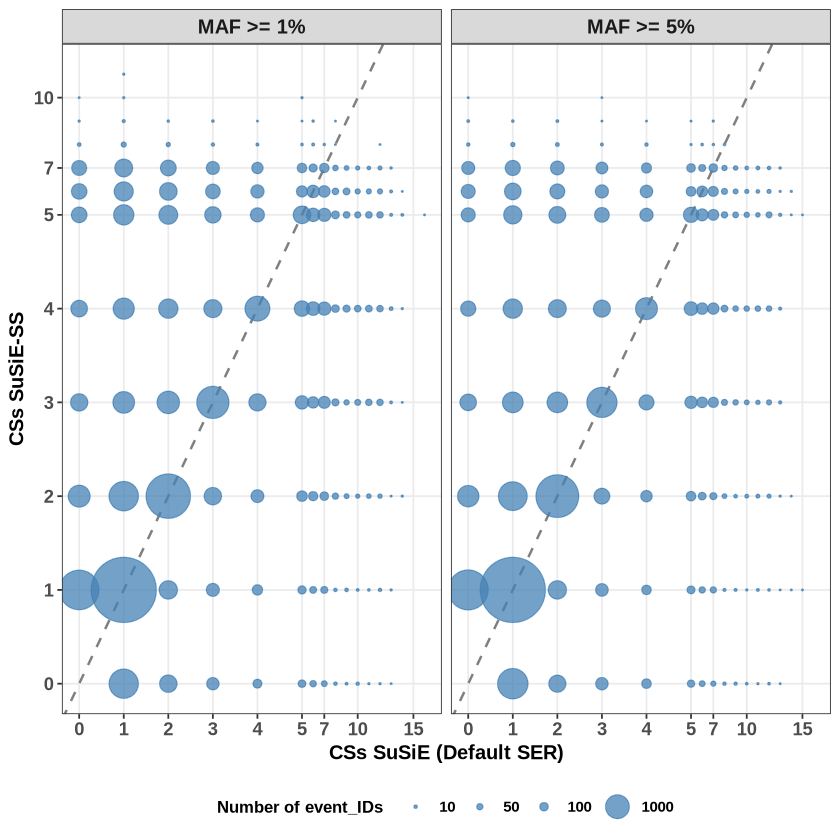

In [21]:
expand_low <- scales::trans_new(
  name      = 'expand_low',
  transform = function(x) ifelse(x <= 5, x * 4,       20 + (x - 5) * 1),
  inverse   = function(y) ifelse(y <= 20, y / 4, 5 + (y - 20) * 1)
)

p_panel_d <- ggplot(panel_d_data, aes(x = cs_std, y = cs_ss, size = n_event_ids)) +
  geom_abline(slope = 1, intercept = 0,
              linetype = 'dashed', color = 'gray50', linewidth = 0.7) +
  geom_point(alpha = 0.75, color = 'steelblue') +
  scale_size_area(
    max_size = 18,
    breaks   = c(10, 50, 100, 1000),
    name     = 'Number of event_IDs'
  ) +
  scale_x_continuous(trans = expand_low, breaks = c(0, 1, 2, 3, 4, 5, 7, 10, 15)) +
  scale_y_continuous(trans = expand_low, breaks = c(0, 1, 2, 3, 4, 5, 7, 10)) +
  facet_wrap(~maf, nrow = 1) +
  labs(
    x     = 'CSs SuSiE (Default SER)',
    y     = 'CSs SuSiE-SS'
  ) +
  theme_bw() +
  theme(
    axis.text        = element_text(face = 'bold', size = 11),
    axis.title       = element_text(face = 'bold', size = 12),
    plot.title       = element_text(face = 'bold', size = 12),
    strip.text       = element_text(face = 'bold', size = 12),
    legend.position  = 'bottom',
    legend.title     = element_text(face = 'bold', size = 10),
    legend.text      = element_text(face = 'bold', size = 9),
    panel.grid.minor = element_blank()
  )

ggsave('panel_D_cs_dotplot.png', p_panel_d, width = 14, height = 6, dpi = 300, bg = 'white')
p_panel_d

## 6. Panel D (extended) - breakdown by coverage threshold

Total CS counts across the three coverage thresholds (95%, 70%, 50%) side-by-side,
showing how the number of called CS changes with the threshold.

# A tibble: 4 × 4
  Condition      `95%`  `70%`  `50%`
  <fct>          <int>  <int>  <int>
1 SuSiE MAF5     78699  85983  88193
2 SuSiE MAF1     97500 104294 106285
3 SuSiE-SS MAF5  96509 100462 101079
4 SuSiE-SS MAF1 118400 122303 122889


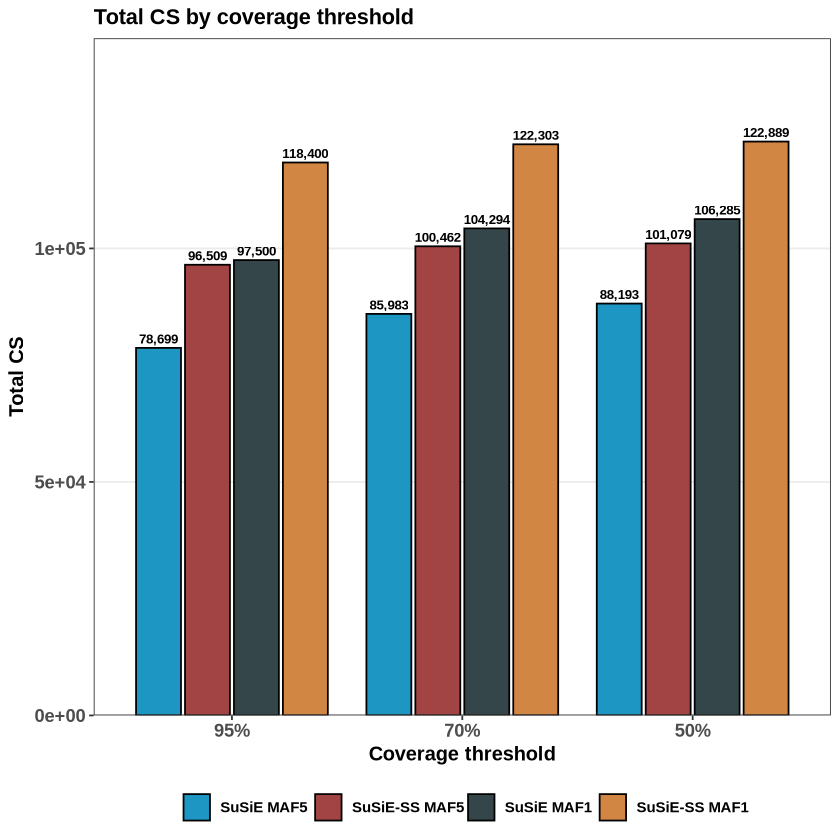

In [22]:
coverage_map <- c(
  '95%' = 'n_cs_95',
  '70%' = 'n_cs_70',
  '50%' = 'n_cs_50'
)

# MAF5 together then MAF1 together, SuSiE before SuSiE-SS within each group
cond_order <- c('SuSiE MAF5', 'SuSiE-SS MAF5', 'SuSiE MAF1', 'SuSiE-SS MAF1')
cond_colors <- c(
  'SuSiE MAF5'    = COLORS[['std_maf5']],
  'SuSiE-SS MAF5' = COLORS[['ss_maf5']],
  'SuSiE MAF1'    = COLORS[['std_maf1']],
  'SuSiE-SS MAF1' = COLORS[['ss_maf1']]
)

cov_tbl <- map_dfr(names(LABELS), function(key) {
  d <- ev_list[[key]]
  map_dfr(names(coverage_map), function(cov_label) {
    col <- coverage_map[[cov_label]]
    tibble(
      Condition = LABELS[[key]],
      Coverage  = cov_label,
      Total_CS  = sum(d[[col]])
    )
  })
}) %>%
  mutate(
    Coverage  = factor(Coverage, levels = names(coverage_map)),
    Condition = factor(Condition, levels = cond_order)
  )

print(cov_tbl %>% pivot_wider(names_from = Coverage, values_from = Total_CS, id_cols = Condition))

p_cov <- ggplot(cov_tbl, aes(x = Coverage, y = Total_CS, fill = Condition)) +
  geom_col(position = position_dodge(width = 0.85), width = 0.78,
           color = 'black', linewidth = 0.5) +
  geom_text(aes(label = comma(Total_CS)),
            position = position_dodge(width = 0.85),
            vjust = -0.5, size = 2.8, fontface = 'bold') +
  scale_fill_manual(values = cond_colors) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.18))) +
  labs(x = 'Coverage threshold', y = 'Total CS', fill = NULL,
       title = 'Total CS by coverage threshold') +
  theme_bw() +
  theme(
    axis.text          = element_text(face = 'bold', size = 11),
    axis.title         = element_text(face = 'bold', size = 12),
    plot.title         = element_text(face = 'bold', size = 13),
    legend.position    = 'bottom',
    legend.text        = element_text(face = 'bold', size = 9),
    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank()
  )

ggsave('cs_by_coverage_type.png', p_cov, width = 12, height = 5, dpi = 300, bg = 'white')
p_cov

In [23]:
for (info in list(
  list(method = 'SuSiE',    key5 = 'std_maf5', key1 = 'std_maf1'),
  list(method = 'SuSiE-SS', key5 = 'ss_maf5',  key1 = 'ss_maf1')
)) {
  cs5 <- ev_list[[info$key5]]$event_ID[ev_list[[info$key5]]$has_cs]
  cs1 <- ev_list[[info$key1]]$event_ID[ev_list[[info$key1]]$has_cs]

  new_in_maf1  <- setdiff(cs1, cs5)
  lost_in_maf1 <- setdiff(cs5, cs1)

  cat(glue('\n{info$method}\n'))
  cat(glue('  event_IDs with CS (MAF5): {length(cs5)}\n'))
  cat(glue('  event_IDs with CS (MAF1): {length(cs1)}\n'))
  cat(glue('  New event_IDs gained by lowering MAF (MAF1 only): {length(new_in_maf1)}\n'))
  cat(glue('  event_IDs lost when lowering MAF (MAF5 only)    : {length(lost_in_maf1)}\n'))
}

SuSiEevent_IDs with CS (MAF5): 31797event_IDs with CS (MAF1): 36292New event_IDs gained by lowering MAF (MAF1 only): 6900event_IDs lost when lowering MAF (MAF5 only)    : 2405SuSiE-SSevent_IDs with CS (MAF5): 34498event_IDs with CS (MAF1): 39480New event_IDs gained by lowering MAF (MAF1 only): 6717event_IDs lost when lowering MAF (MAF5 only)    : 1735

## 7. CS size distribution (number of variants per CS)

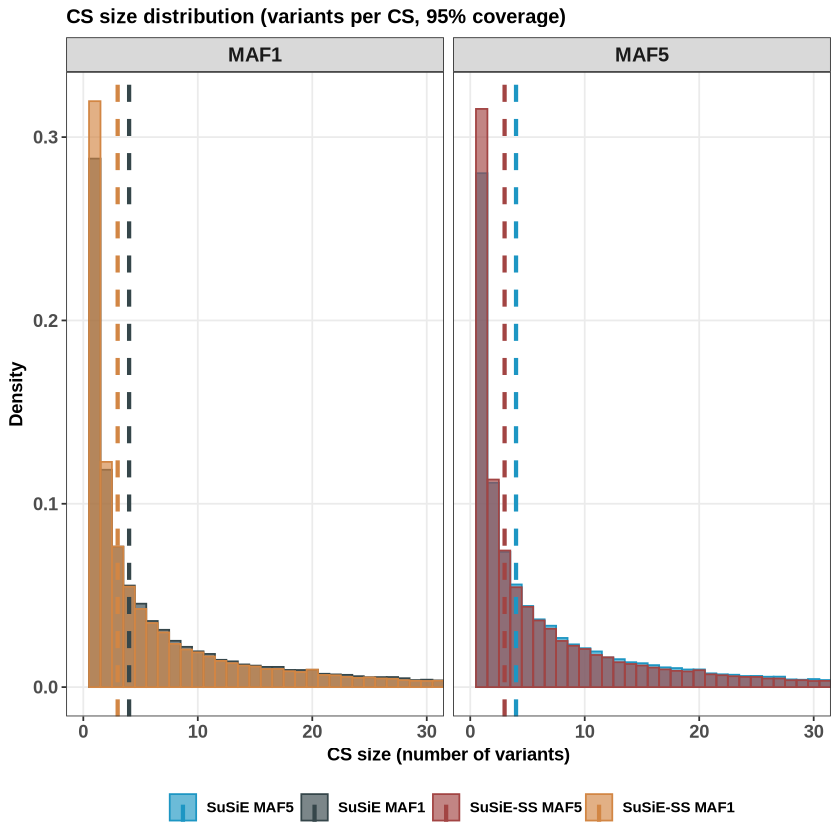

In [24]:
cs_sizes <- function(df, cs_col = 'cs_coverage_0.95') {
  df %>%
    filter(.data[[cs_col]] != 0L) %>%
    group_by(event_ID, .data[[cs_col]]) %>%
    summarise(size = n(), .groups = 'drop') %>%
    pull(size)
}

size_data <- bind_rows(
  tibble(size = cs_sizes(data_list[['std_maf5']]), label = LABELS['std_maf5'], maf = 'MAF5'),
  tibble(size = cs_sizes(data_list[['ss_maf5']]),  label = LABELS['ss_maf5'],  maf = 'MAF5'),
  tibble(size = cs_sizes(data_list[['std_maf1']]), label = LABELS['std_maf1'], maf = 'MAF1'),
  tibble(size = cs_sizes(data_list[['ss_maf1']]),  label = LABELS['ss_maf1'],  maf = 'MAF1')
) %>%
  mutate(label = factor(label, levels = LABELS))

median_df <- size_data %>%
  group_by(label, maf) %>%
  summarise(med = median(size), .groups = 'drop')

p_sizes <- ggplot(size_data, aes(x = size, fill = label, color = label)) +
  geom_histogram(aes(y = after_stat(density)),
                 binwidth = 1, alpha = 0.65, position = 'identity',
                 boundary = 0.5) +
  geom_vline(data = median_df,
             aes(xintercept = med, color = label),
             linetype = 'dashed', linewidth = 1.2) +
  scale_fill_manual(values  = setNames(COLORS, LABELS)) +
  scale_color_manual(values = setNames(COLORS, LABELS)) +
  coord_cartesian(xlim = c(0, 30)) +
  facet_wrap(~maf, nrow = 1) +
  labs(
    title = 'CS size distribution (variants per CS, 95% coverage)',
    x     = 'CS size (number of variants)',
    y     = 'Density',
    fill  = NULL,
    color = NULL
  ) +
  theme_bw() +
  theme(
    axis.text        = element_text(face = 'bold', size = 11),
    axis.title       = element_text(face = 'bold', size = 11),
    plot.title       = element_text(face = 'bold', size = 12),
    strip.text       = element_text(face = 'bold', size = 12),
    legend.position  = 'bottom',
    legend.text      = element_text(face = 'bold', size = 9),
    panel.grid.minor = element_blank()
  )

ggsave('cs_size_distribution.png', p_sizes, width = 14, height = 5, dpi = 300, bg = 'white')
p_sizes

## 8. Export summary tables

In [25]:
for (key in names(ev_list)) {
  fname <- glue('event_cs_summary_{key}.tsv')
  write_tsv(ev_list[[key]], fname)
  message(glue('Saved {fname}  ({nrow(ev_list[[key]])} rows)'))
}

write_tsv(summary_tbl, 'summary_table.tsv')
message('Saved summary_table.tsv')

Saved event_cs_summary_std_maf5.tsv  (54361 rows)

Saved event_cs_summary_std_maf1.tsv  (56762 rows)

Saved event_cs_summary_ss_maf5.tsv  (62364 rows)

Saved event_cs_summary_ss_maf1.tsv  (63984 rows)

Saved summary_table.tsv

